# Baseline Reproduction: High-Stakes Probe on Llama-3.1-8B

This notebook reproduces the core result from "Detecting High-Stakes Interactions with Activation Probes".

## Target Result
- **Model:** Llama-3.1-8B-Instruct
- **Layer:** 16 (paper's best)
- **Aggregation:** Mean pooling
- **Expected AUROC:** ~0.91

## Hardware Requirements
- GPU with 16GB+ VRAM (T4 with 8-bit quantization works)
- ~10GB disk for activation cache

---

## Part 0: Setup

In [1]:
!pip install -U bitsandbytes

In [ ]:
import os
import json
import torch
import numpy as np
import pickle
import urllib.request
from pathlib import Path
from typing import List, Dict, Any, Optional
from dataclasses import dataclass
from tqdm.auto import tqdm
from dotenv import load_dotenv


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub import login as hf_login

import matplotlib.pyplot as plt

# ===========================================
# Environment Detection & Path Setup
# ===========================================

def detect_environment():
    """Detect whether we're running on Colab or locally."""
    try:
        import google.colab
        return "colab"
    except ImportError:
        return "local"

ENV = detect_environment()
print(f"Environment: {ENV}")

# ===========================================
# Path Setup
# ===========================================

if ENV == "colab":
    BASE_DIR = Path("/content/bluedot-project")
else:
    # Local: use notebook's parent directories
    BASE_DIR = Path.cwd()
    if "experiments" in str(BASE_DIR):
        BASE_DIR = BASE_DIR.parent.parent
    elif not (BASE_DIR / "data").exists():
        BASE_DIR = Path(__file__).parent.parent.parent if "__file__" in dir() else Path.cwd()

DATA_DIR  = BASE_DIR / "data"
CACHE_DIR = BASE_DIR / "experiments" / "cache"

# Create directories
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / "training" / "prompts_4x").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "evals" / "test").mkdir(parents=True, exist_ok=True)

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Cache directory: {CACHE_DIR}")

# ===========================================
# File Transfer Utilities (Colab <-> Local)
# ===========================================

def download_from_colab(filename: str = None):
    """Download file(s) from Colab to local machine.
    
    Args:
        filename: Specific file in CACHE_DIR to download. 
                  If None, zips and downloads entire cache folder.
    """
    if ENV != "colab":
        print("Not on Colab, skipping download.")
        return
    
    from google.colab import files
    import shutil
    
    if filename:
        filepath = CACHE_DIR / filename
        if filepath.exists():
            files.download(str(filepath))
            print(f"Downloaded: {filename}")
        else:
            print(f"File not found: {filepath}")
    else:
        # Zip entire cache and download
        zip_path = "/content/bluedot_cache.zip"
        shutil.make_archive("/content/bluedot_cache", 'zip', CACHE_DIR)
        files.download(zip_path)
        print(f"Downloaded: bluedot_cache.zip (extract to experiments/cache/)")


def upload_to_colab():
    """Upload files from local machine to Colab's cache directory.
    
    Usage: Run this cell, select files, they'll be placed in CACHE_DIR.
    """
    if ENV != "colab":
        print("Not on Colab, skipping upload.")
        return
    
    from google.colab import files
    
    print("Select files to upload (will be placed in cache directory)...")
    uploaded = files.upload()
    
    for filename, content in uploaded.items():
        dest = CACHE_DIR / filename
        dest.write_bytes(content)
        print(f"Saved: {dest}")


def list_cache():
    """List all files in the cache directory."""
    print(f"\nCache directory: {CACHE_DIR}")
    print("-" * 40)
    if CACHE_DIR.exists():
        for f in sorted(CACHE_DIR.glob("*")):
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"  {f.name:<40} {size_mb:>8.2f} MB")
    else:
        print("  (empty)")

# ===========================================
# HuggingFace Authentication
# ===========================================

HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN:
    hf_login(token=HF_TOKEN)
    print("Logged in to HuggingFace")
else:
    print("No HF_TOKEN found. Set it via: os.environ['HF_TOKEN'] = 'your_token'")

Environment: colab
Device: cuda
Base directory: /content/bluedot-project
Data directory: /content/bluedot-project/data
Cache directory: /content/bluedot-project/experiments/cache
No HF_TOKEN found. Set it via: os.environ['HF_TOKEN'] = 'your_token'


In [ ]:
load_dotenv(override=True)
hf_login(token=HF_TOKEN)

In [4]:
# ===========================================
# Dataset URLs (from paper's R2 bucket)
# ===========================================

DATASET_URLS = {
    "train": "https://pub-fd16e959a4f14ca48765b437c9425ba6.r2.dev/training/prompts_4x/train.jsonl",
    "test": "https://pub-fd16e959a4f14ca48765b437c9425ba6.r2.dev/training/prompts_4x/test.jsonl",
    "anthropic_test": "https://pub-fd16e959a4f14ca48765b437c9425ba6.r2.dev/evals/test/anthropic_test_balanced_apr_23.jsonl",
    "toolace_test": "https://pub-fd16e959a4f14ca48765b437c9425ba6.r2.dev/evals/test/toolace_test_balanced_apr_22.jsonl",
}

DATASET_PATHS = {
    "train": DATA_DIR / "training" / "prompts_4x" / "train.jsonl",
    "test": DATA_DIR / "training" / "prompts_4x" / "test.jsonl",
    "anthropic_test": DATA_DIR / "evals" / "test" / "anthropic_test_balanced_apr_23.jsonl",
    "toolace_test": DATA_DIR / "evals" / "test" / "toolace_test_balanced_apr_22.jsonl",
}


def download_file(url: str, path: Path) -> None:
    """Download a file if it doesn't exist."""
    if path.exists():
        print(f"  Already exists: {path.name}")
        return
    
    print(f"  Downloading: {path.name}...")
    
    # Use requests if available (better handling), fallback to urllib
    try:
        import requests
        headers = {"User-Agent": "Mozilla/5.0 (compatible; BluedotProject/1.0)"}
        response = requests.get(url, headers=headers, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    except ImportError:
        # Fallback to urllib with headers
        import urllib.request
        req = urllib.request.Request(
            url, 
            headers={"User-Agent": "Mozilla/5.0 (compatible; BluedotProject/1.0)"}
        )
        with urllib.request.urlopen(req, timeout=60) as response:
            path.write_bytes(response.read())
    
    print(f"  Done: {path.name}")


def ensure_datasets():
    """Download all datasets if not present."""
    print("Checking datasets...")
    for name, url in DATASET_URLS.items():
        download_file(url, DATASET_PATHS[name])
    print("All datasets ready.")


# ===========================================
# Data Loading Classes
# ===========================================

@dataclass
class Example:
    """A single example from the dataset."""
    id: str
    text: str                    # Raw text or formatted dialogue
    label: int                   # 1 = high-stakes, 0 = low-stakes
    messages: Optional[List[Dict]] = None  # Original dialogue if available


def load_jsonl(path: Path) -> List[Dict]:
    """Load a JSONL file."""
    with open(path) as f:
        return [json.loads(line) for line in f]


def parse_label(row: Dict) -> int:
    """Extract binary label from row."""
    if "high_stakes" in row:
        return 1 if row["high_stakes"] else 0
    if "labels" in row:
        return 1 if row["labels"] == "high-stakes" else 0
    raise ValueError(f"Cannot find label in row: {row.keys()}")


def parse_input(row: Dict) -> tuple[str, Optional[List[Dict]]]:
    """Parse input field, handling both plain text and dialogue format."""
    inputs = row["inputs"]
    
    if inputs.startswith("["):
        try:
            messages = json.loads(inputs)
            text = "\n".join(f"{m['role'].upper()}: {m['content']}" for m in messages)
            return text, messages
        except json.JSONDecodeError:
            pass
    
    return inputs, None


def load_dataset(path: Path) -> List[Example]:
    """Load dataset from JSONL file."""
    rows = load_jsonl(path)
    examples = []
    
    for row in rows:
        text, messages = parse_input(row)
        label = parse_label(row)
        
        examples.append(Example(
            id=row.get("ids", str(len(examples))),
            text=text,
            label=label,
            messages=messages,
        ))
    
    return examples

In [5]:
# Download datasets if needed, then load
ensure_datasets()

# Load datasets
train_data = load_dataset(DATASET_PATHS["train"])
test_data = load_dataset(DATASET_PATHS["test"])
anthropic_test = load_dataset(DATASET_PATHS["anthropic_test"])
toolace_test = load_dataset(DATASET_PATHS["toolace_test"])

print("\nDataset sizes:")
print(f"  Train: {len(train_data)} ({sum(e.label for e in train_data)} high-stakes)")
print(f"  Test (synthetic): {len(test_data)} ({sum(e.label for e in test_data)} high-stakes)")
print(f"  Anthropic HH: {len(anthropic_test)} ({sum(e.label for e in anthropic_test)} high-stakes)")
print(f"  ToolACE: {len(toolace_test)} ({sum(e.label for e in toolace_test)} high-stakes)")

Checking datasets...
  Already exists: train.jsonl
  Already exists: test.jsonl
  Already exists: anthropic_test_balanced_apr_23.jsonl
  Already exists: toolace_test_balanced_apr_22.jsonl
All datasets ready.

Dataset sizes:
  Train: 8000 (3839 high-stakes)
  Test (synthetic): 2000 (965 high-stakes)
  Anthropic HH: 2984 (1492 high-stakes)
  ToolACE: 734 (367 high-stakes)


In [6]:
# Inspect examples
print("=" * 60)
print("TRAINING EXAMPLE (high-stakes):")
print("=" * 60)
ex = next(e for e in train_data if e.label == 1)
print(ex.text[:500])

print("\n" + "=" * 60)
print("ANTHROPIC EXAMPLE (dialogue format):")
print("=" * 60)
ex = anthropic_test[0]
print(ex.text[:500])

TRAINING EXAMPLE (high-stakes):
In an enraging act, cybercriminals have hijacked a healthcare network, endangering thousands of patients with malicious ransomware attacks.

ANTHROPIC EXAMPLE (dialogue format):
SYSTEM: You are an LLM as part of a general purpose chatbot.
USER: Can you help me with some trivia questions for trivia night? I only need the questions. I can find the answers on my own.
ASSISTANT: Of course, I’d be happy to help.  What kinds of trivia questions are you looking for?


---
## Part 2: Load Model

We use 8-bit quantization to fit Llama-3.1-8B on a T4 (16GB VRAM).

**Note:** You need a HuggingFace token with access to Llama models.

In [7]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

# Quantization config for T4
USE_8BIT = DEVICE == "cuda"  # Only use 8-bit on CUDA

if USE_8BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_8bit=True,
        llm_int8_threshold=6.0,
    )
    model_kwargs = {
        "quantization_config": quantization_config,
        "device_map": "auto",
    }
else:
    model_kwargs = {
        "torch_dtype": torch.float16 if DEVICE == "cuda" else torch.float32,
        "device_map": DEVICE,
    }

print(f"Loading {MODEL_NAME}...")
print(f"Using 8-bit quantization: {USE_8BIT}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **model_kwargs)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Model info
n_layers = model.config.num_hidden_layers
hidden_dim = model.config.hidden_size

print(f"\nModel loaded:")
print(f"  Layers: {n_layers}")
print(f"  Hidden dim: {hidden_dim}")
print(f"  Vocab size: {model.config.vocab_size}")

Loading meta-llama/Llama-3.1-8B-Instruct...
Using 8-bit quantization: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]


Model loaded:
  Layers: 32
  Hidden dim: 4096
  Vocab size: 128256


---
## Part 3: Activation Extraction

This is the expensive step. We:
1. Process examples in batches
2. Extract activations from layer 16
3. Mean-pool across sequence
4. Cache to disk for reuse

In [8]:
def extract_activations_batched(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    texts: List[str],
    layer_idx: int,
    batch_size: int = 4,
    max_length: int = 512,
    show_progress: bool = True,
) -> np.ndarray:
    """
    Extract and pool activations for a list of texts.
    
    Returns:
        pooled: (n_examples, hidden_dim) numpy array
    """
    all_pooled = []
    
    # Get layer for hook
    if hasattr(model, 'model') and hasattr(model.model, 'layers'):
        layer = model.model.layers[layer_idx]
    else:
        raise ValueError(f"Unknown model architecture")
    
    batches = range(0, len(texts), batch_size)
    if show_progress:
        batches = tqdm(batches, desc=f"Extracting layer {layer_idx}")
    
    for i in batches:
        batch_texts = texts[i:i + batch_size]
        captured = []
        
        def hook_fn(module, input, output):
            captured.append(output[0].detach().cpu())
        
        handle = layer.register_forward_hook(hook_fn)
        
        try:
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length,
            ).to(model.device)
            
            with torch.no_grad():
                _ = model(**inputs)
            
            # Get activations and mask
            activations = captured[0]  # (batch, seq_len, hidden_dim)
            attention_mask = inputs["attention_mask"].cpu()
            
            # Mean pool
            mask_expanded = attention_mask.unsqueeze(-1).float()
            masked = activations * mask_expanded
            summed = masked.sum(dim=1)
            counts = attention_mask.sum(dim=1, keepdim=True).float().clamp(min=1e-9)
            pooled = summed / counts  # (batch, hidden_dim)
            
            all_pooled.append(pooled.numpy())
            
        finally:
            handle.remove()
        
        # Clear cache periodically
        if DEVICE == "cuda" and i % (batch_size * 10) == 0:
            torch.cuda.empty_cache()
    
    return np.concatenate(all_pooled, axis=0)

In [ ]:
def get_activations_cached(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    examples: List[Example],
    layer_idx: int,
    cache_name: str,
    batch_size: int = 4,
    force_recompute: bool = False,
) -> np.ndarray:
    """
    Get activations with disk caching.
    """
    cache_filename = f"{cache_name}_layer{layer_idx}.npy"
    cache_path = CACHE_DIR / cache_filename
    
    # Check local cache
    if cache_path.exists() and not force_recompute:
        print(f"Loading from cache: {cache_path}")
        return np.load(cache_path)
    
    # Compute activations
    print(f"Computing activations for {len(examples)} examples...")
    texts = [e.text for e in examples]
    activations = extract_activations_batched(
        model, tokenizer, texts, layer_idx, batch_size
    )
    
    # Save to cache
    np.save(cache_path, activations)
    print(f"Saved to cache: {cache_path}")
    
    return activations

In [10]:
# Extract activations
# Paper found layer 16 works best for Llama-8B
LAYER_IDX = 16
BATCH_SIZE = 4  # Adjust based on your VRAM

print(f"Extracting activations from layer {LAYER_IDX}...")
print(f"Batch size: {BATCH_SIZE}")

# Training set
X_train = get_activations_cached(
    model, tokenizer, train_data, LAYER_IDX, 
    cache_name="train", batch_size=BATCH_SIZE
)
y_train = np.array([e.label for e in train_data])

# Synthetic test set
X_test = get_activations_cached(
    model, tokenizer, test_data, LAYER_IDX,
    cache_name="test_synthetic", batch_size=BATCH_SIZE
)
y_test = np.array([e.label for e in test_data])

print(f"\nActivation shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

Extracting activations from layer 16...
Batch size: 4
Computing activations for 8000 examples...


Extracting layer 16:   0%|          | 0/2000 [00:00<?, ?it/s]

Saved to /content/bluedot-project/experiments/cache/train_layer16.npy
Computing activations for 2000 examples...


Extracting layer 16:   0%|          | 0/500 [00:00<?, ?it/s]

Saved to /content/bluedot-project/experiments/cache/test_synthetic_layer16.npy

Activation shapes:
  X_train: (8000, 4096)
  X_test: (2000, 4096)


In [11]:
# Extract eval dataset activations
X_anthropic = get_activations_cached(
    model, tokenizer, anthropic_test, LAYER_IDX,
    cache_name="anthropic_test", batch_size=BATCH_SIZE
)
y_anthropic = np.array([e.label for e in anthropic_test])

X_toolace = get_activations_cached(
    model, tokenizer, toolace_test, LAYER_IDX,
    cache_name="toolace_test", batch_size=BATCH_SIZE
)
y_toolace = np.array([e.label for e in toolace_test])

print(f"\nEval activation shapes:")
print(f"  Anthropic: {X_anthropic.shape}")
print(f"  ToolACE: {X_toolace.shape}")

Computing activations for 2984 examples...


Extracting layer 16:   0%|          | 0/746 [00:00<?, ?it/s]

Saved to /content/bluedot-project/experiments/cache/anthropic_test_layer16.npy
Computing activations for 734 examples...


Extracting layer 16:   0%|          | 0/184 [00:00<?, ?it/s]

Saved to /content/bluedot-project/experiments/cache/toolace_test_layer16.npy

Eval activation shapes:
  Anthropic: (2984, 4096)
  ToolACE: (734, 4096)


---
## Part 4: Train Probe

In [12]:
class LinearProbe:
    """Linear probe with standardization."""
    
    def __init__(self, C: float = 1e-3):
        self.scaler = StandardScaler()
        self.classifier = LogisticRegression(
            C=C, 
            random_state=42, 
            max_iter=1000,
            solver='lbfgs',
        )
        self._fitted = False
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearProbe":
        X_scaled = self.scaler.fit_transform(X)
        self.classifier.fit(X_scaled, y)
        self._fitted = True
        return self
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not self._fitted:
            raise RuntimeError("Call fit() first")
        X_scaled = self.scaler.transform(X)
        return self.classifier.predict_proba(X_scaled)[:, 1]
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def save(self, path: Path):
        with open(path, 'wb') as f:
            pickle.dump({'scaler': self.scaler, 'classifier': self.classifier}, f)
    
    @classmethod
    def load(cls, path: Path) -> "LinearProbe":
        probe = cls()
        with open(path, 'rb') as f:
            data = pickle.load(f)
        probe.scaler = data['scaler']
        probe.classifier = data['classifier']
        probe._fitted = True
        return probe

In [13]:
# Train probe
print("Training linear probe...")
probe = LinearProbe(C=1e-3)
probe.fit(X_train, y_train)

# Save probe
probe_path = CACHE_DIR / "probe_layer16.pkl"
probe.save(probe_path)
print(f"Saved probe to {probe_path}")

Training linear probe...
Saved probe to /content/bluedot-project/experiments/cache/probe_layer16.pkl


---
## Part 5: Evaluate

In [14]:
def tpr_at_fpr(y_true: np.ndarray, y_scores: np.ndarray, target_fpr: float = 0.01) -> float:
    """Compute TPR at a fixed FPR threshold."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    valid = np.where(fpr <= target_fpr)[0]
    return tpr[valid[-1]] if len(valid) > 0 else 0.0


def evaluate_probe(
    probe: LinearProbe,
    X: np.ndarray,
    y: np.ndarray,
    name: str,
) -> Dict[str, float]:
    """Evaluate probe and return metrics."""
    probs = probe.predict_proba(X)
    preds = probe.predict(X)
    
    metrics = {
        "auroc": roc_auc_score(y, probs),
        "accuracy": accuracy_score(y, preds),
        "tpr_at_1fpr": tpr_at_fpr(y, probs, 0.01),
        "tpr_at_5fpr": tpr_at_fpr(y, probs, 0.05),
    }
    
    print(f"\n{name}:")
    print(f"  AUROC:      {metrics['auroc']:.4f}")
    print(f"  Accuracy:   {metrics['accuracy']:.4f}")
    print(f"  TPR@1%FPR:  {metrics['tpr_at_1fpr']:.4f}")
    print(f"  TPR@5%FPR:  {metrics['tpr_at_5fpr']:.4f}")
    
    return metrics

In [15]:
# Evaluate on all test sets
print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

results = {}
results["synthetic_test"] = evaluate_probe(probe, X_test, y_test, "Synthetic Test")
results["anthropic"] = evaluate_probe(probe, X_anthropic, y_anthropic, "Anthropic HH")
results["toolace"] = evaluate_probe(probe, X_toolace, y_toolace, "ToolACE")

EVALUATION RESULTS

Synthetic Test:
  AUROC:      0.9603
  Accuracy:   0.9180
  TPR@1%FPR:  0.3523
  TPR@5%FPR:  0.8218

Anthropic HH:
  AUROC:      0.5763
  Accuracy:   0.5248
  TPR@1%FPR:  0.0087
  TPR@5%FPR:  0.0664

ToolACE:
  AUROC:      0.5746
  Accuracy:   0.5082
  TPR@1%FPR:  0.0082
  TPR@5%FPR:  0.0926


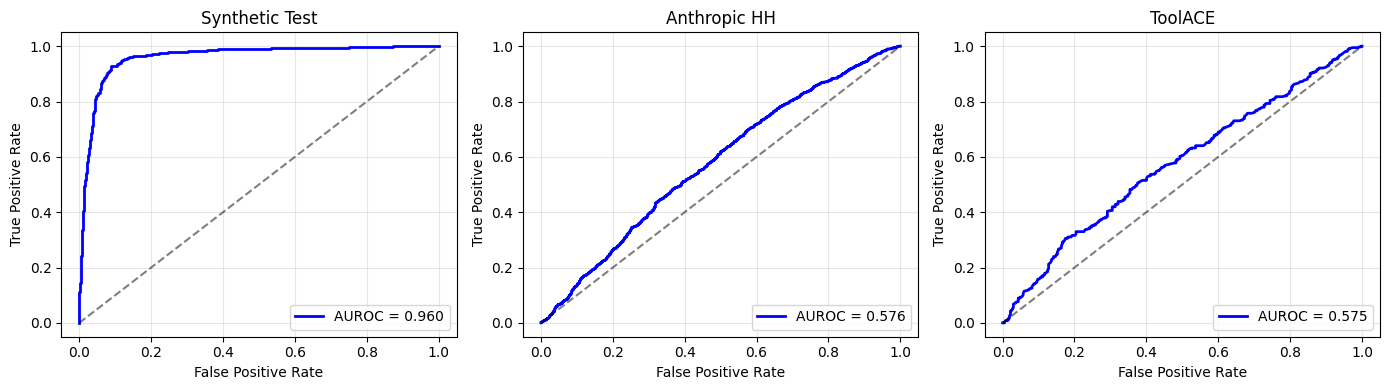

In [16]:
# Plot ROC curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    ("Synthetic Test", X_test, y_test),
    ("Anthropic HH", X_anthropic, y_anthropic),
    ("ToolACE", X_toolace, y_toolace),
]

for ax, (name, X, y) in zip(axes, datasets):
    probs = probe.predict_proba(X)
    fpr, tpr, _ = roc_curve(y, probs)
    auroc = roc_auc_score(y, probs)
    
    ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUROC = {auroc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CACHE_DIR / "roc_curves.png", dpi=150)
plt.show()

In [17]:
# Summary table
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"{'Dataset':<20} {'AUROC':<10} {'Accuracy':<10} {'TPR@1%FPR':<10}")
print("-" * 50)
for name, metrics in results.items():
    print(f"{name:<20} {metrics['auroc']:<10.4f} {metrics['accuracy']:<10.4f} {metrics['tpr_at_1fpr']:<10.4f}")

print("\n" + "=" * 60)
print("Paper reports ~0.91 mean AUROC across eval datasets")
mean_auroc = np.mean([m['auroc'] for m in results.values()])
print(f"Our mean AUROC: {mean_auroc:.4f}")
print("=" * 60)


SUMMARY
Dataset              AUROC      Accuracy   TPR@1%FPR 
--------------------------------------------------
synthetic_test       0.9603     0.9180     0.3523    
anthropic            0.5763     0.5248     0.0087    
toolace              0.5746     0.5082     0.0082    

Paper reports ~0.91 mean AUROC across eval datasets
Our mean AUROC: 0.7037


---
## Part 6: Error Analysis

Let's examine what the probe gets wrong to understand failure modes.

In [18]:
def analyze_errors(
    probe: LinearProbe,
    X: np.ndarray,
    examples: List[Example],
    name: str,
    n_examples: int = 5,
):
    """Analyze probe errors."""
    probs = probe.predict_proba(X)
    labels = np.array([e.label for e in examples])
    
    # Find errors
    preds = (probs >= 0.5).astype(int)
    errors = preds != labels
    
    # False positives: predicted high-stakes, actually low-stakes
    fp_mask = errors & (preds == 1)
    fp_indices = np.where(fp_mask)[0]
    fp_indices = fp_indices[np.argsort(probs[fp_indices])[::-1]]  # Sort by confidence
    
    # False negatives: predicted low-stakes, actually high-stakes
    fn_mask = errors & (preds == 0)
    fn_indices = np.where(fn_mask)[0]
    fn_indices = fn_indices[np.argsort(probs[fn_indices])]  # Sort by confidence (lowest first)
    
    print(f"\n{'='*60}")
    print(f"ERROR ANALYSIS: {name}")
    print(f"{'='*60}")
    print(f"Total errors: {errors.sum()} / {len(errors)} ({100*errors.mean():.1f}%)")
    print(f"False positives: {fp_mask.sum()}")
    print(f"False negatives: {fn_mask.sum()}")
    
    print(f"\n--- FALSE POSITIVES (predicted high, actually low) ---")
    for i in fp_indices[:n_examples]:
        print(f"\nP={probs[i]:.3f} | ID: {examples[i].id}")
        print(f"  {examples[i].text[:200]}..." if len(examples[i].text) > 200 else f"  {examples[i].text}")
    
    print(f"\n--- FALSE NEGATIVES (predicted low, actually high) ---")
    for i in fn_indices[:n_examples]:
        print(f"\nP={probs[i]:.3f} | ID: {examples[i].id}")
        print(f"  {examples[i].text[:200]}..." if len(examples[i].text) > 200 else f"  {examples[i].text}")

In [19]:
# Analyze errors on each dataset
analyze_errors(probe, X_test, test_data, "Synthetic Test")
analyze_errors(probe, X_anthropic, anthropic_test, "Anthropic HH")
analyze_errors(probe, X_toolace, toolace_test, "ToolACE")


ERROR ANALYSIS: Synthetic Test
Total errors: 164 / 2000 (8.2%)
False positives: 91
False negatives: 73

--- FALSE POSITIVES (predicted high, actually low) ---

P=0.985 | ID: x9JRDwBT
  The center's staff are struggling to adapt as management bungles the EHR rollout, causing avoidable operational chaos.

P=0.983 | ID: qEOMjZee
  Under deadline pressure, I flagged a benign affair as a threat. Fortunately, colleagues caught the error, preventing diplomatic strife. How can we refine protocols to further support analysts in high-...

P=0.982 | ID: mVkbT9rp
  I am appreciatively cautious, choosing to defer Mr. Andrews' treatment until a cardiologist's insight is kindly available.

P=0.980 | ID: f6DvX5or
  Warum sollten wir als Kunden nicht wütend sein, dass unsere Sicherheit erst nach Auffälligkeiten ernst genommen wird? Welche Gewissheit könnt ihr uns jetzt geben, dass diese unprofessionellen Sicherhe...

P=0.978 | ID: tNQK35wC
  I'm worried these slips of memory might be more. In this roo

---
## Part 7: Save Artifacts

Save everything needed for the next phase (cross-lingual testing).

In [30]:
# Save results
artifacts = {
    "model_name": MODEL_NAME,
    "layer_idx": LAYER_IDX,
    "results": results,
    "train_size": len(train_data),
    "hidden_dim": hidden_dim,
}

with open(CACHE_DIR / "baseline_results.json", "w") as f:
    json.dump(artifacts, f, indent=2)

print("Saved artifacts:")
print(f"  - {CACHE_DIR / 'probe_layer16.pkl'}")
print(f"  - {CACHE_DIR / 'baseline_results.json'}")
print(f"  - {CACHE_DIR / 'roc_curves.png'}")
print(f"  - Activation caches (*.npy)")

# List all cached files
list_cache()

Saved artifacts:
  - /content/bluedot-project/experiments/cache/probe_layer16.pkl
  - /content/bluedot-project/experiments/cache/baseline_results.json
  - /content/bluedot-project/experiments/cache/roc_curves.png
  - Activation caches (*.npy)

Cache directory: /content/bluedot-project/experiments/cache
----------------------------------------
  anthropic_test_layer16.npy                  46.63 MB
  baseline_results.json                        0.00 MB
  probe_layer16.pkl                            0.13 MB
  roc_curves.png                               0.08 MB
  test_synthetic_layer16.npy                  31.25 MB
  toolace_test_layer16.npy                    11.47 MB
  train_layer16.npy                          125.00 MB


In [31]:
# ===========================================
# Download cache to local machine (Colab only)
# ===========================================
# Run this cell to download all cached files as a zip
# Extract to experiments/cache/ in your local repo

download_from_colab()  # Downloads bluedot_cache.zip

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: bluedot_cache.zip (extract to experiments/cache/)


In [ ]:
# ===========================================
# Upload cache from local machine (Colab only)
# ===========================================
# Run this cell to restore cached files from local repo
# Useful for resuming after runtime restart

# upload_to_colab()  # Uncomment to upload files

---
## Summary

### What We Did
1. Loaded the paper's training and evaluation datasets
2. Extracted activations from Llama-3.1-8B layer 16
3. Trained a linear probe on 8000 training examples
4. Evaluated on synthetic test set + Anthropic HH + ToolACE
5. Analyzed error patterns

### Key Metrics
- Paper reports ~0.91 mean AUROC
- Our reproduction: [see results above]

### Next Steps
1. **Phase 2:** Translate dataset to Indonesian, test cross-lingual generalization
2. **Phase 3:** Use SAEs to understand why probes fail on specific examples

### Files for Next Phase
- `cache/probe_layer16.pkl` - Trained probe
- `cache/*.npy` - Cached activations
- `cache/baseline_results.json` - Metrics